## Session 3: Shot map of the Euro 2025 final

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch

events = sb.events(match_id=4020846)

In [2]:
shots = events[(events["type"] == "Shot") & (events["period"] < 5)].copy()
shots.shape

(31, 88)

In [3]:
shots[["x", "y"]] = pd.DataFrame(shots["location"].tolist(), index=shots.index)
shots[["player", "location", "x", "y"]].head()

,player,location,x,y
4585,Alessia Russo,"[111.1, 54.8]",111.1,54.8
4586,Esther Gonzalez Rodríguez,"[115.4, 31.1]",115.4,31.1
4587,Esther Gonzalez Rodríguez,"[107.5, 35.5]",107.5,35.5
4588,Athenea del Castillo Belvide,"[103.5, 43.2]",103.5,43.2
4589,Georgia Stanway,"[97.4, 41.0]",97.4,41.0


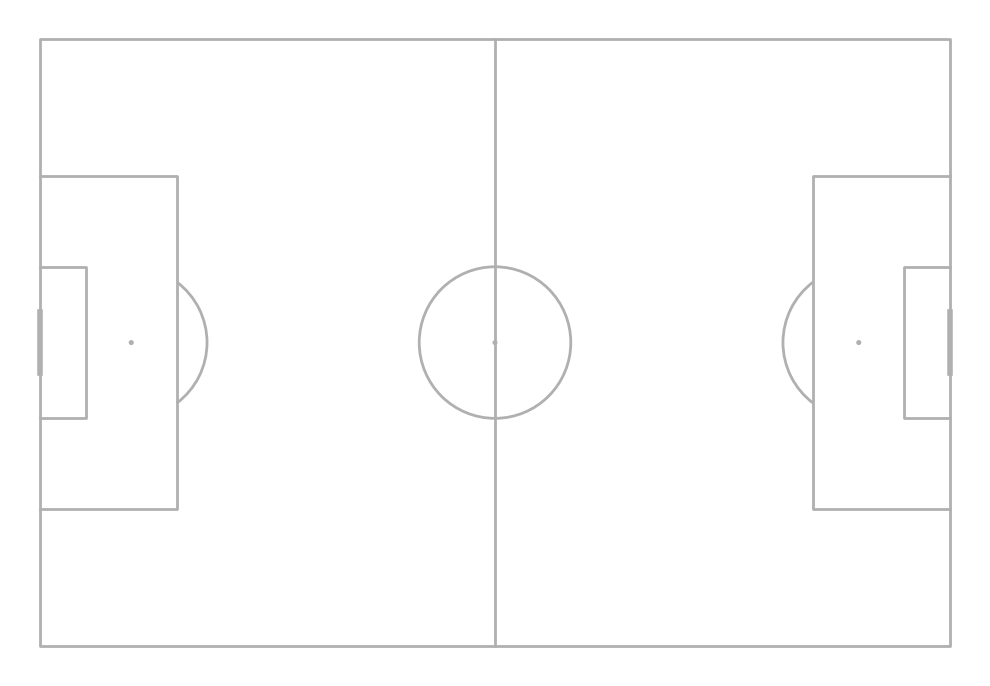

In [4]:
pitch = Pitch(pitch_type="statsbomb")
fig, ax = pitch.draw(figsize=(10, 7))

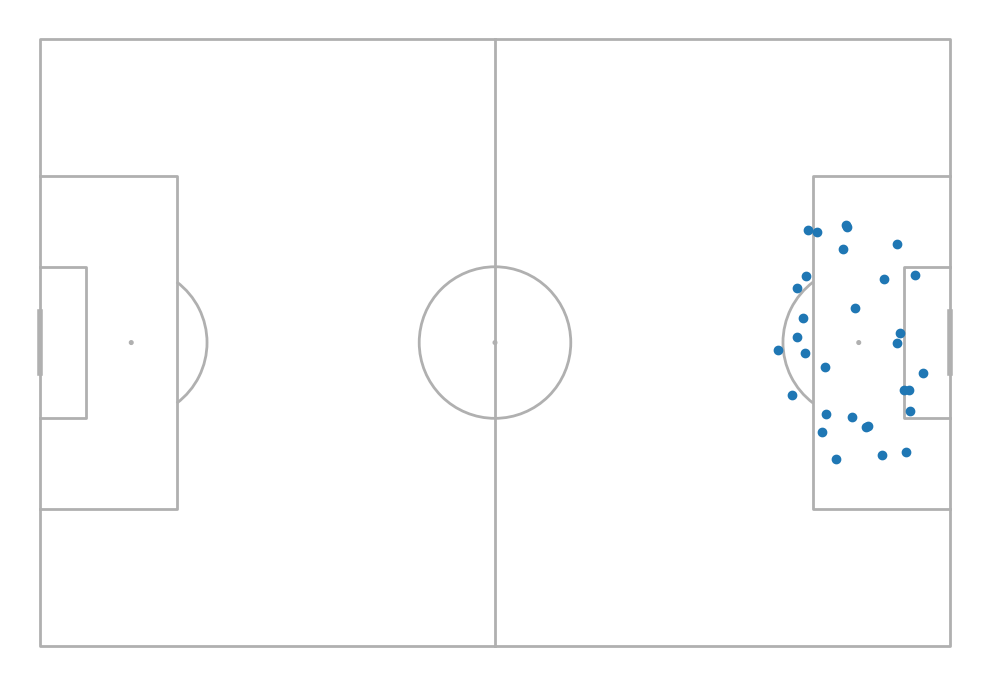

In [5]:
pitch = Pitch(pitch_type="statsbomb")
fig, ax = pitch.draw(figsize=(10, 7))
pitch.scatter(shots["x"], shots["y"], ax=ax)
plt.show()

In [ ]:
england_shots = shots[shots["team"] == "England Women's"]
spain_shots = shots[shots["team"] == "Spain Women's"].copy()

In [ ]:
spain_shots["x"] = 120 - spain_shots["x"]
spain_shots["y"] = 80 - spain_shots["y"]

NameError: name 'england_shots' is not defined

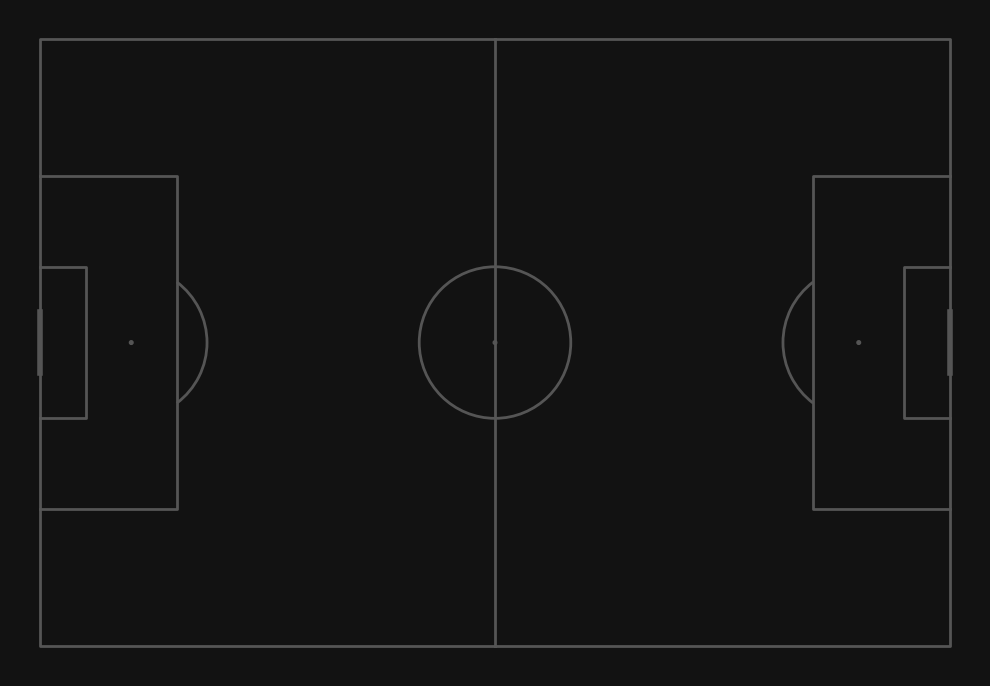

In [6]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#121212", line_color="#555555")
fig, ax = pitch.draw(figsize=(10, 7))
fig.set_facecolor("#121212")

pitch.scatter(england_shots["x"], england_shots["y"], ax=ax,
              color="#FF5C9D", label="England")
pitch.scatter(spain_shots["x"], spain_shots["y"], ax=ax,
              color="white", label="Spain")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
plt.show()

In [7]:
england_shots = shots[shots["team"] == "England Women's"]
spain_shots = shots[shots["team"] == "Spain Women's"].copy()

In [8]:
spain_shots["x"] = 120 - spain_shots["x"]
spain_shots["y"] = 80 - spain_shots["y"]

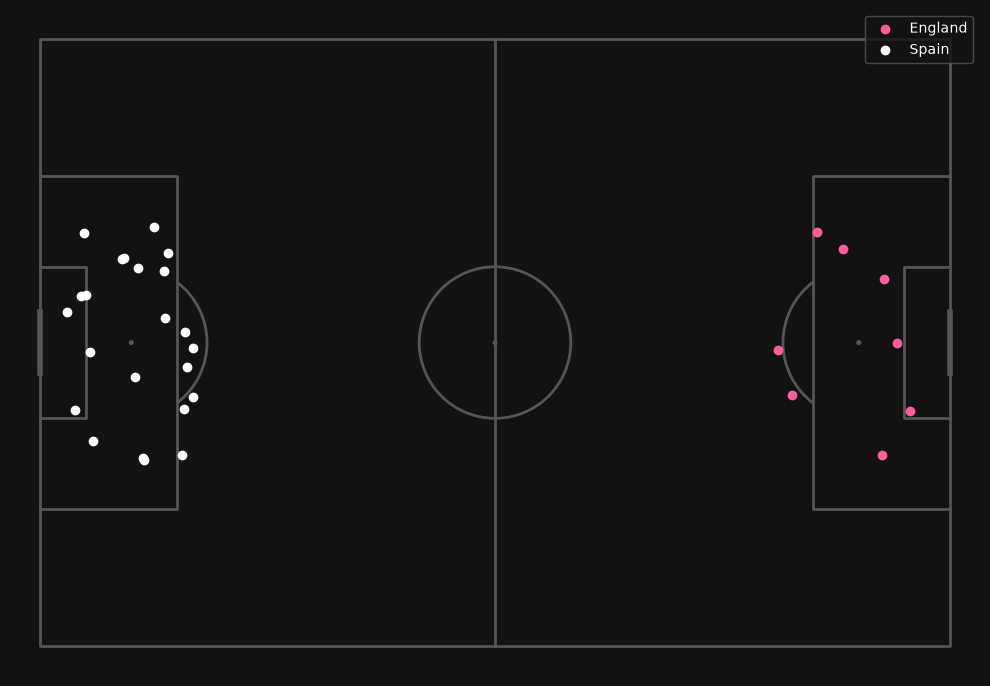

In [9]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#121212", line_color="#555555")
fig, ax = pitch.draw(figsize=(10, 7))
fig.set_facecolor("#121212")

pitch.scatter(england_shots["x"], england_shots["y"], ax=ax,
              color="#FF5C9D", label="England")
pitch.scatter(spain_shots["x"], spain_shots["y"], ax=ax,
              color="white", label="Spain")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
plt.show()

In [10]:
england_goals = england_shots[england_shots["shot_outcome"] == "Goal"]
spain_goals = spain_shots[spain_shots["shot_outcome"] == "Goal"]

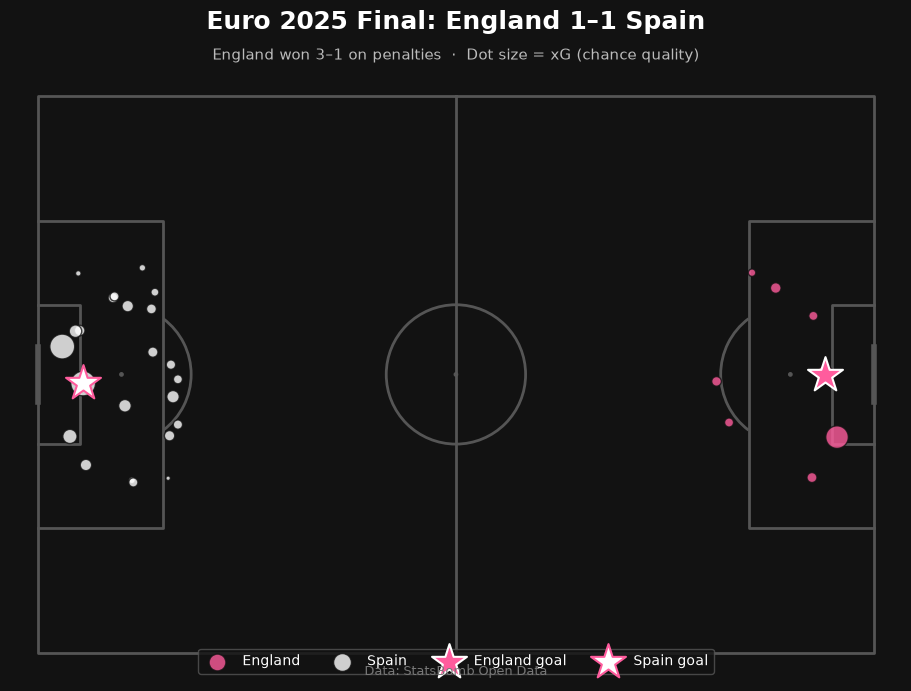

In [11]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#121212", line_color="#555555")
fig, ax = pitch.draw(figsize=(10, 7))
fig.set_facecolor("#121212")

# All shots, sized by xG
pitch.scatter(england_shots["x"], england_shots["y"], ax=ax,
              s=england_shots["shot_statsbomb_xg"] * 800,
              color="#FF5C9D", edgecolors="#121212", alpha=0.8,
              label="England", zorder=2)
pitch.scatter(spain_shots["x"], spain_shots["y"], ax=ax,
              s=spain_shots["shot_statsbomb_xg"] * 800,
              color="white", edgecolors="#121212", alpha=0.8,
              label="Spain", zorder=2)

# Goals as stars, drawn on top
pitch.scatter(england_goals["x"], england_goals["y"], ax=ax,
              s=700, marker="*", color="#FF5C9D", edgecolors="white",
              linewidths=1.5, label="England goal", zorder=3)
pitch.scatter(spain_goals["x"], spain_goals["y"], ax=ax,
              s=700, marker="*", color="white", edgecolors="#FF5C9D",
              linewidths=1.5, label="Spain goal", zorder=3)

# Title, subtitle and credit
fig.suptitle("Euro 2025 Final: England 1–1 Spain", color="white",
             fontsize=18, fontweight="bold")
ax.set_title("England won 3–1 on penalties  ·  Dot size = xG (chance quality)",
             color="#BBBBBB", fontsize=11)
fig.text(0.5, 0.03, "Data: StatsBomb Open Data", color="#777777",
         fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white",
          loc="lower center", ncol=4)
plt.show()

In [12]:
xg_summary = shots.groupby("team")["shot_statsbomb_xg"].agg(["count", "sum", "mean"]).round(2)
xg_summary

,count,sum,mean
team,,,
England Women's,8,0.88,0.11
Spain Women's,23,2.14,0.09


In [13]:
in_box = shots[(shots["x"] >= 102) & (shots["y"] >= 18) & (shots["y"] <= 62)]
in_box["team"].value_counts()

team
Spain Women's      17
England Women's     6
Name: count, dtype: int64

In [14]:
fig.savefig("shot_map_euro2025_final.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")